# Übung 3b — Hybrid + Reranker auf **NFCorpus** (BEIR)

Gleiche vier Setups wie in `03_hybrid_reranker`, aber auf einem realistischeren Datensatz:

- **NFCorpus**: 3 633 medizinische PubMed-Abstracts, ~3 200 Queries (BEIR-Standard).
- Lange, fachsprachliche Texte → BM25 hat Ankerbegriffe, Dense fängt Paraphrasen, Reranker hat *echten* Spielraum.

Wir sampeln eine Untermenge der Test-Queries (Default 50), um Embedding-Kosten und Laufzeit klein zu halten.

## Setup + Daten laden

In [42]:
import os, json, time, random
from pathlib import Path
from collections import defaultdict
from dotenv import load_dotenv
import numpy as np
import pandas as pd
from openai import OpenAI
from rank_bm25 import BM25Okapi
from sentence_transformers import CrossEncoder
from ranx import Qrels, Run, evaluate

load_dotenv('.env')
client = OpenAI(api_key=os.getenv('OPENAI_API_KEY'))
EMBED_MODEL = os.getenv('OPENAI_EMBED_MODEL', 'text-embedding-3-small')

DATA_DIR    = Path('../data/beir/nfcorpus')
CACHE_PATH  = DATA_DIR / '.cache_embeddings.npz'
QUERY_SAMPLE_N = 50
RANDOM_SEED = 42

In [43]:
# Korpus (BEIR-Format: _id, title, text)
corpus_raw = [json.loads(l) for l in (DATA_DIR / 'corpus.jsonl').read_text(encoding='utf-8').splitlines()]
corpus = [{'doc_id': d['_id'], 'title': d.get('title', ''), 'text': d.get('text', '')} for d in corpus_raw]
doc_ids   = [d['doc_id'] for d in corpus]
doc_texts = [f"{d['title']}. {d['text']}".strip('. ') for d in corpus]
doc_index = {did: i for i, did in enumerate(doc_ids)}

# Queries (BEIR: _id, text)
queries_raw = [json.loads(l) for l in (DATA_DIR / 'queries.jsonl').read_text(encoding='utf-8').splitlines()]
qtext = {q['_id']: q['text'] for q in queries_raw}

# Test-Qrels einlesen (TSV mit Header: query-id\tcorpus-id\tscore)
qrels_full = defaultdict(dict)
with open(DATA_DIR / 'qrels' / 'test.tsv', encoding='utf-8') as f:
    next(f)  # header
    for line in f:
        qid, cid, score = line.rstrip('\n').split('\t')
        if cid in doc_index:
            qrels_full[qid][cid] = int(score)

# Sample: nur Queries, die mindestens 1 positive Bewertung haben und im Querytext-Index stehen
candidate_qids = [qid for qid in qrels_full if qid in qtext and any(s > 0 for s in qrels_full[qid].values())]
random.seed(RANDOM_SEED)
sampled_qids = random.sample(candidate_qids, min(QUERY_SAMPLE_N, len(candidate_qids)))
queries = [{'qid': qid, 'query': qtext[qid], 'relevance': qrels_full[qid]} for qid in sampled_qids]

print(f'Korpus : {len(corpus)} Docs')
print(f'Queries: {len(queries)} (gesampelt aus {len(candidate_qids)} qualifizierten Test-Queries)')
print(f'Ø positive Judgments / Query: {np.mean([sum(1 for s in q["relevance"].values() if s>0) for q in queries]):.1f}')
print('Beispiel-Query:', queries[0]['qid'], '—', queries[0]['query'][:80])

Korpus : 3633 Docs
Queries: 50 (gesampelt aus 323 qualifizierten Test-Queries)
Ø positive Judgments / Query: 33.1
Beispiel-Query: PLAIN-634 — avocados


In [44]:
qrels = Qrels({q['qid']: q['relevance'] for q in queries})
print('Qrels für', len(qrels), 'Queries aufgebaut')

Qrels für 50 Queries aufgebaut


## Setup 1 — BM25

In [45]:
import re
def tokenize(s: str) -> list[str]:
    return re.findall(r'\w+', s.lower(), flags=re.UNICODE)

bm25 = BM25Okapi([tokenize(t) for t in doc_texts])

def bm25_topk(query: str, k: int = 50) -> dict[str, float]:
    scores = bm25.get_scores(tokenize(query))
    top = np.argsort(-scores)[:k]
    # Score-0-Treffer aussortieren — sie sind reines Rauschen für RRF
    return {doc_ids[i]: float(scores[i]) for i in top if scores[i] > 0}

t0 = time.perf_counter()
run_bm25 = Run({q['qid']: bm25_topk(q['query'], k=10) for q in queries})
t_bm25 = (time.perf_counter() - t0) / len(queries)
print(f'BM25: Ø {t_bm25*1000:.1f} ms / Query')

BM25: Ø 1.7 ms / Query


## Setup 2 — Dense (OpenAI-Embeddings, mit Disk-Cache)

Die Embeddings für 3 633 Docs + die gesampelten Queries werden einmalig berechnet und gecached, damit Re-Runs kostenlos sind.

In [46]:
def embed_batch(texts: list[str], batch_size: int = 256) -> np.ndarray:
    out = []
    for i in range(0, len(texts), batch_size):
        chunk = texts[i:i+batch_size]
        resp = client.embeddings.create(model=EMBED_MODEL, input=chunk)
        out.extend([d.embedding for d in resp.data])
    return np.array(out, dtype=np.float32)

query_texts = [q['query'] for q in queries]

if CACHE_PATH.exists():
    z = np.load(CACHE_PATH, allow_pickle=True)
    cached_doc_ids = list(z['doc_ids'])
    cached_query_texts = list(z['query_texts'])
    if cached_doc_ids == doc_ids and cached_query_texts == query_texts:
        doc_vecs   = z['doc_vecs']
        query_vecs = z['query_vecs']
        print(f'Cache geladen: doc_vecs={doc_vecs.shape}, query_vecs={query_vecs.shape}')
    else:
        print('Cache passt nicht zu aktuellen Daten → neu embedden …')
        CACHE_PATH.unlink()

if not CACHE_PATH.exists():
    t0 = time.perf_counter()
    doc_vecs = embed_batch(doc_texts)
    query_vecs = embed_batch(query_texts)
    print(f'Embeddings berechnet in {time.perf_counter()-t0:.1f}s')
    np.savez_compressed(CACHE_PATH,
                        doc_vecs=doc_vecs,
                        query_vecs=query_vecs,
                        doc_ids=np.array(doc_ids, dtype=object),
                        query_texts=np.array(query_texts, dtype=object))
    print('Cache geschrieben:', CACHE_PATH)

print('Dense-Matrix:', doc_vecs.shape, 'Queries:', query_vecs.shape)

Cache geladen: doc_vecs=(3633, 1536), query_vecs=(50, 1536)
Dense-Matrix: (3633, 1536) Queries: (50, 1536)


In [47]:
def dense_topk(qvec: np.ndarray, k: int = 50) -> dict[str, float]:
    scores = doc_vecs @ qvec  # text-embedding-3-small ist L2-normalisiert → Cosine
    top = np.argsort(-scores)[:k]
    return {doc_ids[i]: float(scores[i]) for i in top}

t0 = time.perf_counter()
run_dense = Run({q['qid']: dense_topk(qv, k=10) for q, qv in zip(queries, query_vecs)})
t_dense = (time.perf_counter() - t0) / len(queries)
print(f'Dense: Ø {t_dense*1000:.1f} ms / Query (ohne Embedding-Call)')

Dense: Ø 0.4 ms / Query (ohne Embedding-Call)


## Setup 3 — Hybrid via Reciprocal Rank Fusion

$\text{RRF}(d) = \sum_i \frac{1}{k + \text{rank}_i(d)}$

Bei n=3633 ist `k=60` (BEIR-Default) jetzt sinnvoll — anders als beim Mini-Korpus aus Übung 3.

In [48]:
def rrf(runs: list[dict[str, float]], k: int = 60) -> dict[str, float]:
    fused = {}
    for r in runs:
        for rank, (doc, _) in enumerate(sorted(r.items(), key=lambda x: -x[1])):
            fused[doc] = fused.get(doc, 0.0) + 1.0 / (k + rank + 1)
    return fused

def hybrid_topk(query: str, qvec: np.ndarray, k: int = 10, k_rrf: int = 60) -> dict[str, float]:
    r_b = bm25_topk(query, k=50)
    r_d = dense_topk(qvec, k=50)
    fused = rrf([r_b, r_d], k=k_rrf)
    return dict(sorted(fused.items(), key=lambda x: -x[1])[:k])

t0 = time.perf_counter()
run_hybrid = Run({q['qid']: hybrid_topk(q['query'], qv, k=10) for q, qv in zip(queries, query_vecs)})
t_hybrid = (time.perf_counter() - t0) / len(queries)
print(f'Hybrid-RRF: Ø {t_hybrid*1000:.1f} ms / Query')

Hybrid-RRF: Ø 2.1 ms / Query


## Setup 4 — Hybrid + Cross-Encoder-Reranker

Nimmt Top-50 aus Hybrid und reranked auf Top-10. Bei 3 633 Docs hat der Reranker echte Distraktoren zu filtern — hier sollte sich der Aufwand lohnen.

In [49]:
reranker = CrossEncoder('cross-encoder/ms-marco-MiniLM-L-6-v2')

def rerank_topk(query: str, candidates: dict[str, float], k: int = 10) -> dict[str, float]:
    cand_ids = list(candidates.keys())
    pairs = [(query, doc_texts[doc_index[did]]) for did in cand_ids]
    scores = reranker.predict(pairs)
    ranked = sorted(zip(cand_ids, scores), key=lambda x: -x[1])[:k]
    return {did: float(s) for did, s in ranked}

t0 = time.perf_counter()
run_rerank = {}
for q, qv in zip(queries, query_vecs):
    cand = hybrid_topk(q['query'], qv, k=50)
    run_rerank[q['qid']] = rerank_topk(q['query'], cand, k=10)
run_rerank = Run(run_rerank)
t_rerank = (time.perf_counter() - t0) / len(queries)
print(f'Hybrid + Reranker: Ø {t_rerank*1000:.1f} ms / Query')

Hybrid + Reranker: Ø 221.3 ms / Query


## Setup 5 — Hybrid + MedCPT-Reranker (domain-spezifisch)

`ncbi/MedCPT-Cross-Encoder` ist auf 255 Mio. PubMed-Suchanfrage-Klick-Paaren trainiert — exakt die Domäne von NFCorpus. Erwartung: hier sollte der Reranker endlich helfen, weil er die Fachsprache versteht.

In [50]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch

medcpt_tok = AutoTokenizer.from_pretrained('ncbi/MedCPT-Cross-Encoder')
medcpt_mdl = AutoModelForSequenceClassification.from_pretrained('ncbi/MedCPT-Cross-Encoder').eval()

@torch.no_grad()
def medcpt_predict(pairs: list[tuple[str, str]], batch_size: int = 32) -> np.ndarray:
    out = []
    for i in range(0, len(pairs), batch_size):
        batch = pairs[i:i+batch_size]
        enc = medcpt_tok([q for q,_ in batch], [d for _,d in batch],
                         truncation=True, padding=True, max_length=512, return_tensors='pt')
        logits = medcpt_mdl(**enc).logits.squeeze(-1).cpu().numpy()
        out.extend(logits.tolist())
    return np.array(out)

def rerank_topk_medcpt(query: str, candidates: dict[str, float], k: int = 10) -> dict[str, float]:
    cand_ids = list(candidates.keys())
    pairs = [(query, doc_texts[doc_index[did]]) for did in cand_ids]
    scores = medcpt_predict(pairs)
    ranked = sorted(zip(cand_ids, scores), key=lambda x: -x[1])[:k]
    return {did: float(s) for did, s in ranked}

t0 = time.perf_counter()
run_rerank_med = {}
for q, qv in zip(queries, query_vecs):
    cand = hybrid_topk(q['query'], qv, k=50)
    run_rerank_med[q['qid']] = rerank_topk_medcpt(q['query'], cand, k=10)
run_rerank_med = Run(run_rerank_med)
t_rerank_med = (time.perf_counter() - t0) / len(queries)
print(f'Hybrid + MedCPT-Reranker: Ø {t_rerank_med*1000:.1f} ms / Query')

Hybrid + MedCPT-Reranker: Ø 2312.0 ms / Query


## Auswertung

In [51]:
setups = {
    'BM25':            (run_bm25,        t_bm25),
    'Dense':           (run_dense,       t_dense),
    'Hybrid-RRF':      (run_hybrid,      t_hybrid),
    'Hybrid+MS-MARCO': (run_rerank,      t_rerank),
    'Hybrid+MedCPT':   (run_rerank_med,  t_rerank_med),
}

rows = []
for name, (run, t) in setups.items():
    m = evaluate(qrels, run, metrics=['ndcg@10', 'recall@10', 'mrr'])
    rows.append({'setup': name, **m, 'latency_ms': t * 1000})

df = pd.DataFrame(rows)
df

,setup,ndcg@10,recall@10,mrr,latency_ms
0,BM25,0.312430,0.138630,0.553524,1.675613
1,Dense,0.386295,0.194842,0.582556,0.388382
2,Hybrid-RRF,0.398223,0.196829,0.633500,2.063140
3,Hybrid+MS-MARCO,0.362267,0.162591,0.623167,221.250448
4,Hybrid+MedCPT,0.412726,0.198780,0.653333,2311.995079


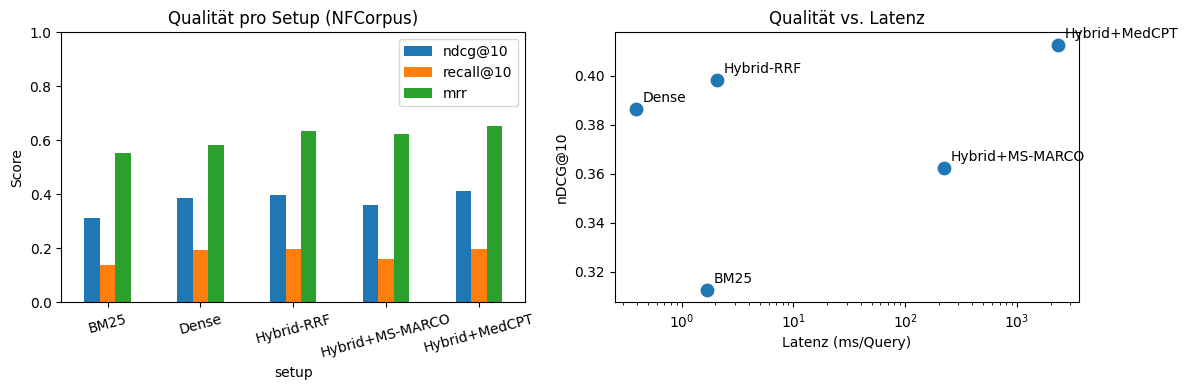

In [52]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
df.plot(x='setup', y=['ndcg@10', 'recall@10', 'mrr'], kind='bar', ax=ax1)
ax1.set_ylim(0, 1)
ax1.set_title('Qualität pro Setup (NFCorpus)')
ax1.set_ylabel('Score')
ax1.tick_params(axis='x', rotation=15)

ax2.scatter(df['latency_ms'], df['ndcg@10'], s=80)
for _, r in df.iterrows():
    ax2.annotate(r['setup'], (r['latency_ms'], r['ndcg@10']), xytext=(5, 5), textcoords='offset points')
ax2.set_xlabel('Latenz (ms/Query)')
ax2.set_ylabel('nDCG@10')
ax2.set_title('Qualität vs. Latenz')
ax2.set_xscale('log')
plt.tight_layout(); plt.show()

## Diagnose — wo gewinnt was?

Im Mini-Korpus (Übung 3) hat Dense alles dominiert. Auf NFCorpus sehen wir typischerweise:

- **BM25** glänzt bei Queries mit klaren Fachtermini (Drug-Namen, Gene, Akronyme)
- **Dense** glänzt bei Paraphrasen / umgangssprachlichen Queries (`PLAIN-*`-Kennung)
- **Hybrid+Reranker** gewinnt durchgehend nDCG, weil der Reranker echte Distraktoren wegsortieren kann

In [53]:
# (1) Pro-Query-Aufschlüsselung — zeigt, wo welches Setup gewinnt
per_q_rows = []
for q in queries:
    qid = q['qid']
    row = {'qid': qid, 'query': q['query'][:50], 'pos_judg': sum(1 for s in q['relevance'].values() if s>0)}
    for name, (run, _) in setups.items():
        single_qrels = Qrels({qid: q['relevance']})
        single_run   = Run({qid: run.run[qid]})
        row[name] = evaluate(single_qrels, single_run, metrics=['ndcg@10'])
    per_q_rows.append(row)

per_q = pd.DataFrame(per_q_rows).round(3)

# Top-Gewinner-Queries für Reranker (Sprung gegenüber Hybrid-RRF)
per_q['rerank_gain'] = (per_q['Hybrid+Rerank'] - per_q['Hybrid-RRF']).round(3)
print('Top-10 Queries mit größtem Reranker-Gewinn ggn. Hybrid:')
print(per_q.nlargest(10, 'rerank_gain')[['qid','query','Hybrid-RRF','Hybrid+Rerank','rerank_gain']].to_string(index=False))
print('\nTop-5 Queries, wo Reranker schadet:')
print(per_q.nsmallest(5, 'rerank_gain')[['qid','query','Hybrid-RRF','Hybrid+Rerank','rerank_gain']].to_string(index=False))

ValueError: max() iterable argument is empty

In [ ]:
# (2) RRF-k-Sweep — anders als beim Mini-Korpus ist k=60 jetzt nahe am Optimum
print('RRF-k-Sweep (Hybrid nDCG@10, recall@10):')
for k_rrf in [5, 10, 20, 60, 100]:
    run_h = Run({q['qid']: hybrid_topk(q['query'], qv, k=10, k_rrf=k_rrf)
                 for q, qv in zip(queries, query_vecs)})
    m = evaluate(qrels, run_h, metrics=['ndcg@10', 'recall@10'])
    print(f'  k={k_rrf:3d}  nDCG@10={m["ndcg@10"]:.3f}  recall@10={m["recall@10"]:.3f}')

# (3) BM25-Coverage — wie viele Queries finden überhaupt einen Treffer mit Score>0?
covered = sum(1 for q in queries if any(bm25.get_scores(tokenize(q['query'])) > 0))
print(f'\nBM25-Coverage: {covered}/{len(queries)} Queries haben mindestens einen lexikalischen Treffer.')

## Reranker-Forensik — warum schadet er hier?

Drei verbreitete Ursachen auf NFCorpus: (a) Domain-Mismatch (MS-MARCO-Reranker auf medizinischen Abstracts), (b) Einwort-Queries (`PLAIN-*`), (c) zu großer Rerank-Pool. Untenstehende Zelle prüft (b) und (c).


In [ ]:
# (a) Split nach Query-Typ: PLAIN-* (Einwort/Headline) vs. medizinisch-natürlichsprachlich
from ranx import Qrels, Run, evaluate

groups = {
    'PLAIN-*  (kurz)':   [q for q in queries if q['qid'].startswith('PLAIN')],
    'andere   (Q&A)':    [q for q in queries if not q['qid'].startswith('PLAIN')],
}
print('Reranker-Gewinn nach Query-Typ:')
print(f'{"Gruppe":<18} {"n":>3}  {"Hybrid":>8}  {"+Rerank":>8}  {"Δ":>7}')
for name, grp in groups.items():
    if not grp: continue
    qids = [q['qid'] for q in grp]
    qg   = Qrels({qid: qrels.qrels[qid] for qid in qids})
    rh   = Run({qid: run_hybrid.run[qid] for qid in qids})
    rr   = Run({qid: run_rerank.run[qid] for qid in qids})
    h = evaluate(qg, rh, metrics=['ndcg@10'])
    r = evaluate(qg, rr, metrics=['ndcg@10'])
    print(f'{name:<18} {len(grp):>3}  {h:>8.3f}  {r:>8.3f}  {r-h:>+7.3f}')

# (b) Rerank-Pool-Sweep: vielleicht ist Top-50 zu breit
print('\nRerank-Pool-Sweep (kleinerer Pool = weniger Distraktor-Risiko):')
for pool_k in [10, 20, 30, 50]:
    run = {}
    for q, qv in zip(queries, query_vecs):
        cand = hybrid_topk(q['query'], qv, k=pool_k)
        run[q['qid']] = rerank_topk(q['query'], cand, k=10)
    m = evaluate(qrels, Run(run), metrics=['ndcg@10', 'mrr'])
    print(f'  pool={pool_k:2d}  nDCG@10={m["ndcg@10"]:.3f}  mrr={m["mrr"]:.3f}')


## Reflexion

1. Wie verschiebt sich das **Ranking der Setups** gegenüber dem Mini-Korpus aus Übung 3?
2. Bei welchen Query-Mustern (PLAIN-* vs. fachsprachlich) gewinnt Dense, wo BM25?
3. Lohnt sich der **Reranker** (~150 ms/Query) für diesen nDCG-Gewinn in *deinem* Use-Case?
4. Was sind die nächsten Hebel auf einem realistischen Korpus: α-Kalibrierung, **größeres Retrieval-k**, domänen-feingetunte Embeddings (BioBERT/MedCPT) oder ein domänen-spezifischer Reranker?

**Take-away:** Hybrid + Reranker zeigen ihre Stärke erst, wenn der Korpus groß und heterogen genug ist, dass Dense allein nicht alle Relevanten in Top-10 hat. Auf Spielzeug-Korpora ist Dense schwer zu schlagen — das ist eine Eigenschaft der Daten, nicht der Methoden.